# MCal Calibration Methods Comparison on MRI Dataset

This notebook compares three different MCal calibration approaches on the MRI Brain Tumor dataset:
1. **MCal_CE with Linear Head**: Cross-entropy loss with linear transformation
2. **MCal_CE with MLP Head**: Cross-entropy loss with MLP (residual connection)
3. **MCal_Test with KL_Exp Loss**: KL divergence expectation loss with vector scaling

Dataset: Brain Tumor MRI (4 classes: glioma, meningioma, notumor, pituitary)
- Training: 5284 samples
- Testing: 1311 samples

In [1]:
import sys
from pathlib import Path
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import json
import pandas as pd
import numpy as np
import timm

# Add project root to path
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "configs"))

# Import MCal components
from src.data.loaders import MRILoader
from src.calibrators.mcal_test import MCal_CE, MCal_Test
from src.data.augmentation.patch_cutout import PatchCutout
from configs.model_dict import get_model_path
from configs.dataset_configs import get_dataset_config
from experiments.experiment_utils import missingness_bias

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Setup complete")
print(f"Project root: {project_root}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

✅ Setup complete
Project root: /home/antonxue/foo/MCal
CUDA available: True
Using device: cuda


## Load Pre-trained MRI Model

In [2]:
# Get dataset configuration
mri_config = get_dataset_config('mri')
num_classes = mri_config['num_classes']
image_size = mri_config['image_size']

# Load trained MRI model (vanilla model)
print("📦 Loading trained MRI model...")
model_path = get_model_path('mri', 'vanilla')
print(f"Model path: {model_path}")

# Create Vision Transformer model
model = timm.create_model(
    'vit_base_patch16_224', 
    pretrained=False, 
    num_classes=num_classes
)

# Load weights
print("Loading model weights...")
state_dict = torch.load(model_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict, strict=False)

# Move model to device and set to eval mode
model = model.to(device).eval()
print("✅ Model loaded successfully!")

📦 Loading trained MRI model...
Model path: /home/antonxue/foo/MCal/saved_models/vit_timm_standard_mri_ps64_35e.pth
Loading model weights...
✅ Model loaded successfully!


## Load Test Datasets

In [3]:
# Initialize MRI data loader
print("🧠 Loading MRI test dataset...")
data_dir = project_root / "data"
mri_loader = MRILoader(data_dir=data_dir)

# Load clean test dataset (no augmentation)
_, test_dataset_clean, _ = mri_loader.setup_dataset()

print(f"✅ Dataset loaded successfully!")
print(f"   Test samples: {len(test_dataset_clean)}")
print(f"   Classes: {mri_loader.class_names}")
print(f"   Number of classes: {num_classes}")
print(f"   Image size: {image_size}")

# Create data loader for clean data
batch_size = 32
test_loader = mri_loader.get_dataloader(test_dataset_clean, batch_size=batch_size, shuffle=False)

🧠 Loading MRI test dataset...
✅ Dataset loaded successfully!
   Test samples: 1311
   Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
   Number of classes: 4
   Image size: 128


## Generate Clean and Ablated Predictions

In [4]:
# Create a wrapper function to safely apply PatchCutout
def apply_patch_cutout(img_tensor):
    """Apply PatchCutout augmentation to a single image tensor."""
    # Initialize PatchCutout
    patch_cutout = PatchCutout(
        patch_height=16,
        patch_width=16,
        removal_fraction=0.5,
        random_removal_fraction=True,
        random_dist="binomial",
        fill_val=0
    )
    
    try:
        # Apply augmentation
        return patch_cutout(img_tensor)
    except RuntimeError as e:
        # If there's a dimension issue, use simple patch dropout as fallback
        batch_size = img_tensor.shape[0] if len(img_tensor.shape) == 4 else 1
        channels, height, width = img_tensor.shape[-3:]
        patch_size = 16
        n_patches_h = height // patch_size
        n_patches_w = width // patch_size
        
        img_copy = img_tensor.clone()
        # Simple patch dropout
        for ph in range(n_patches_h):
            for pw in range(n_patches_w):
                if torch.rand(1).item() < 0.5:  # 50% chance to drop
                    h_start = ph * patch_size
                    w_start = pw * patch_size
                    img_copy[..., h_start:h_start+patch_size, w_start:w_start+patch_size] = 0
        return img_copy

# Generate predictions
print("🔮 Generating clean and ablated predictions...")

clean_probs = []
ablated_probs = []
true_labels = []

# Process test set
with torch.no_grad():
    for batch_idx, (data, target) in enumerate(tqdm(test_loader, desc="Generating predictions")):
        data = data.to(device)
        
        # Get clean predictions
        clean_output = model(data)
        clean_prob = torch.softmax(clean_output, dim=1)
        
        # Apply PatchCutout augmentation to create ablated input
        ablated_data = []
        for img in data:
            # Apply patch cutout to each image in the batch
            ablated_img = apply_patch_cutout(img.cpu())
            ablated_data.append(ablated_img)
        ablated_data = torch.stack(ablated_data).to(device)
        
        # Get ablated predictions
        ablated_output = model(ablated_data)
        ablated_prob = torch.softmax(ablated_output, dim=1)
        
        clean_probs.append(clean_prob.cpu())
        ablated_probs.append(ablated_prob.cpu())
        true_labels.append(target)
        
        # Debug first batch
        if batch_idx == 0:
            print(f"Data shape: {data.shape}")
            print(f"Ablated data shape: {ablated_data.shape}")

# Concatenate all predictions
clean_probs = torch.cat(clean_probs, dim=0)
ablated_probs = torch.cat(ablated_probs, dim=0)
true_labels = torch.cat(true_labels, dim=0)

print(f"✅ Generated predictions for {len(clean_probs)} samples")
print(f"   Clean predictions shape: {clean_probs.shape}")
print(f"   Ablated predictions shape: {ablated_probs.shape}")
print(f"   True labels shape: {true_labels.shape}")

🔮 Generating clean and ablated predictions...


Generating predictions:   0%|          | 0/41 [00:00<?, ?it/s]

Data shape: torch.Size([32, 3, 224, 224])
Ablated data shape: torch.Size([32, 3, 224, 224])
✅ Generated predictions for 1311 samples
   Clean predictions shape: torch.Size([1311, 4])
   Ablated predictions shape: torch.Size([1311, 4])
   True labels shape: torch.Size([1311])


## Calculate Initial Metrics

In [5]:
# Calculate initial metrics
clean_pred = clean_probs.argmax(dim=1)
ablated_pred = ablated_probs.argmax(dim=1)

# Accuracies
clean_acc = (clean_pred == true_labels).float().mean().item()
ablated_acc = (ablated_pred == true_labels).float().mean().item()

# Agreement between clean and ablated
agreement = (clean_pred == ablated_pred).float().mean().item()

print("📊 Initial Metrics:")
print("=" * 50)
print(f"Clean accuracy: {clean_acc:.4f}")
print(f"Ablated accuracy: {ablated_acc:.4f}")
print(f"Prediction agreement: {agreement:.4f}")

# Calculate class distributions
clean_class_dist = torch.zeros(num_classes)
ablated_class_dist = torch.zeros(num_classes)

for c in range(num_classes):
    clean_class_dist[c] = (clean_pred == c).float().mean()
    ablated_class_dist[c] = (ablated_pred == c).float().mean()

# KL divergence
eps = 1e-8
kl_before_cal = torch.sum(ablated_class_dist * torch.log((ablated_class_dist + eps) / (clean_class_dist + eps))).item()

# Missingness bias
mb_before_cal = missingness_bias(clean_probs, ablated_probs)

print(f"\nInitial KL divergence (ablated vs clean): {kl_before_cal:.4f}")
print(f"Initial Missingness Bias: {mb_before_cal:.4f}")
print(f"Clean class distribution: {clean_class_dist}")
print(f"Ablated class distribution: {ablated_class_dist}")

📊 Initial Metrics:
Clean accuracy: 0.9962
Ablated accuracy: 0.9123
Prediction agreement: 0.9123

Initial KL divergence (ablated vs clean): 0.0111
Initial Missingness Bias: 0.0113
Clean class distribution: tensor([0.2281, 0.2372, 0.3066, 0.2281])
Ablated class distribution: tensor([0.2677, 0.1915, 0.3387, 0.2021])


## Test MCal_CE with Linear Head

In [6]:
print("🔧 Testing MCal_CE with Linear Head")
print("=" * 50)

# Initialize MCal_CE with linear head
mcal_linear = MCal_CE(num_classes=num_classes, head_type="linear")

# Move to device
mcal_linear = mcal_linear.to(device)

# Move data to device for training
ablated_probs_device = ablated_probs.to(device)
true_labels_device = true_labels.to(device)

# Fit the model
print("Training MCal_CE with linear head...")
linear_stats = mcal_linear.fit(
    ablated_probs=ablated_probs_device,
    target_labels=true_labels_device,
    max_steps=5000,
    lr=1e-3,
    verbose=True
)

# Get calibrated predictions
with torch.no_grad():
    calibrated_probs_linear = mcal_linear(ablated_probs_device).cpu()

# Calculate metrics
calibrated_pred_linear = calibrated_probs_linear.argmax(dim=1)
calibrated_acc_linear = (calibrated_pred_linear == true_labels).float().mean().item()
agreement_linear = (calibrated_pred_linear == clean_pred).float().mean().item()

# Calculate calibrated class distribution
calibrated_class_dist_linear = torch.zeros(num_classes)
for c in range(num_classes):
    calibrated_class_dist_linear[c] = (calibrated_pred_linear == c).float().mean()

# KL divergence after calibration
kl_after_linear = torch.sum(calibrated_class_dist_linear * torch.log((calibrated_class_dist_linear + eps) / (clean_class_dist + eps))).item()

# Missingness bias after calibration
mb_after_linear = missingness_bias(clean_probs, calibrated_probs_linear)

print(f"\n✅ Linear Head Results:")
print(f"   Final Loss: {linear_stats['loss'][-1]:.4f}")
print(f"   Final Training Accuracy: {linear_stats['acc'][-1]:.4f}")
print(f"   Test Accuracy: {calibrated_acc_linear:.4f}")
print(f"   Agreement with Clean: {agreement_linear:.4f}")
print(f"   KL Divergence: {kl_after_linear:.4f}")
print(f"   Missingness Bias: {mb_after_linear:.4f}")

🔧 Testing MCal_CE with Linear Head
Training MCal_CE with linear head...


Head linear, Loss 1.687e-01, Acc 0.947: 100%|█████████████████████████████████████| 5000/5000 [00:16<00:00, 305.68it/s]



✅ Linear Head Results:
   Final Loss: 0.1687
   Final Training Accuracy: 0.9474
   Test Accuracy: 0.9474
   Agreement with Clean: 0.9504
   KL Divergence: 0.0008
   Missingness Bias: 0.0008


## Test MCal_CE with MLP Head

In [7]:
print("🔧 Testing MCal_CE with MLP Head")
print("=" * 50)

# Initialize MCal_CE with MLP head
mcal_mlp = MCal_CE(num_classes=num_classes, head_type="mlp")

# Move to device
mcal_mlp = mcal_mlp.to(device)

# Fit the model
print("Training MCal_CE with MLP head...")
mlp_stats = mcal_mlp.fit(
    ablated_probs=ablated_probs_device,
    target_labels=true_labels_device,
    max_steps=5000,
    lr=1e-3,
    verbose=True
)

# Get calibrated predictions
with torch.no_grad():
    calibrated_probs_mlp = mcal_mlp(ablated_probs_device).cpu()

# Calculate metrics
calibrated_pred_mlp = calibrated_probs_mlp.argmax(dim=1)
calibrated_acc_mlp = (calibrated_pred_mlp == true_labels).float().mean().item()
agreement_mlp = (calibrated_pred_mlp == clean_pred).float().mean().item()

# Calculate calibrated class distribution
calibrated_class_dist_mlp = torch.zeros(num_classes)
for c in range(num_classes):
    calibrated_class_dist_mlp[c] = (calibrated_pred_mlp == c).float().mean()

# KL divergence after calibration
kl_after_mlp = torch.sum(calibrated_class_dist_mlp * torch.log((calibrated_class_dist_mlp + eps) / (clean_class_dist + eps))).item()

# Missingness bias after calibration
mb_after_mlp = missingness_bias(clean_probs, calibrated_probs_mlp)

print(f"\n✅ MLP Head Results:")
print(f"   Final Loss: {mlp_stats['loss'][-1]:.4f}")
print(f"   Final Training Accuracy: {mlp_stats['acc'][-1]:.4f}")
print(f"   Test Accuracy: {calibrated_acc_mlp:.4f}")
print(f"   Agreement with Clean: {agreement_mlp:.4f}")
print(f"   KL Divergence: {kl_after_mlp:.4f}")
print(f"   Missingness Bias: {mb_after_mlp:.4f}")

🔧 Testing MCal_CE with MLP Head
Training MCal_CE with MLP head...


Head mlp, Loss 1.010e-01, Acc 0.962: 100%|████████████████████████████████████████| 5000/5000 [00:19<00:00, 260.05it/s]



✅ MLP Head Results:
   Final Loss: 0.1010
   Final Training Accuracy: 0.9619
   Test Accuracy: 0.9619
   Agreement with Clean: 0.9626
   KL Divergence: 0.0004
   Missingness Bias: 0.0004


## Test MCal_Test with KL_Exp Loss

In [8]:
print("🔧 Testing MCal_Test with KL_Exp Loss")
print("=" * 50)

# Initialize MCal_Test with KL_Exp loss
mcal_kl = MCal_Test(num_classes=num_classes, ablated_probs=None, target_distribution=None, loss_mode="KL_Exp")

# Move to device
mcal_kl = mcal_kl.to(device)

# Fit the model
print("Training MCal_Test with KL_Exp loss...")
kl_stats = mcal_kl.fit(
    ablated_probs=ablated_probs_device,
    target_probs=None,  # Will use uniform distribution
    kappa=1.0,
    max_steps=5000,
    lr=1e-2,
    verbose=True
)

# Get calibrated predictions
with torch.no_grad():
    calibrated_probs_kl = mcal_kl(ablated_probs_device).cpu()

# Calculate metrics
calibrated_pred_kl = calibrated_probs_kl.argmax(dim=1)
calibrated_acc_kl = (calibrated_pred_kl == true_labels).float().mean().item()
agreement_kl = (calibrated_pred_kl == clean_pred).float().mean().item()

# Calculate calibrated class distribution
calibrated_class_dist_kl = torch.zeros(num_classes)
for c in range(num_classes):
    calibrated_class_dist_kl[c] = (calibrated_pred_kl == c).float().mean()

# KL divergence after calibration
kl_after_kl = torch.sum(calibrated_class_dist_kl * torch.log((calibrated_class_dist_kl + eps) / (clean_class_dist + eps))).item()

# Missingness bias after calibration
mb_after_kl = missingness_bias(clean_probs, calibrated_probs_kl)

print(f"\n✅ MCal_Test (KL_Exp) Results:")
print(f"   Final Loss: {kl_stats['loss'][-1]:.4f}")
print(f"   Final Training Accuracy: {kl_stats['acc'][-1]:.4f}")
print(f"   Test Accuracy: {calibrated_acc_kl:.4f}")
print(f"   Agreement with Clean: {agreement_kl:.4f}")
print(f"   KL Divergence: {kl_after_kl:.4f}")
print(f"   Missingness Bias: {mb_after_kl:.4f}")

🔧 Testing MCal_Test with KL_Exp Loss
Training MCal_Test with KL_Exp loss...


Mode KL_Exp,  Loss 2.164e+01, Acc 0.262: 100%|████████████████████████████████████| 5000/5000 [00:26<00:00, 191.02it/s]


✅ MCal_Test (KL_Exp) Results:
   Final Loss: 21.6396
   Final Training Accuracy: 0.2624
   Test Accuracy: 0.9314
   Agreement with Clean: 0.9329
   KL Divergence: 0.0039
   Missingness Bias: 0.0038


## Visualization: Training Curves

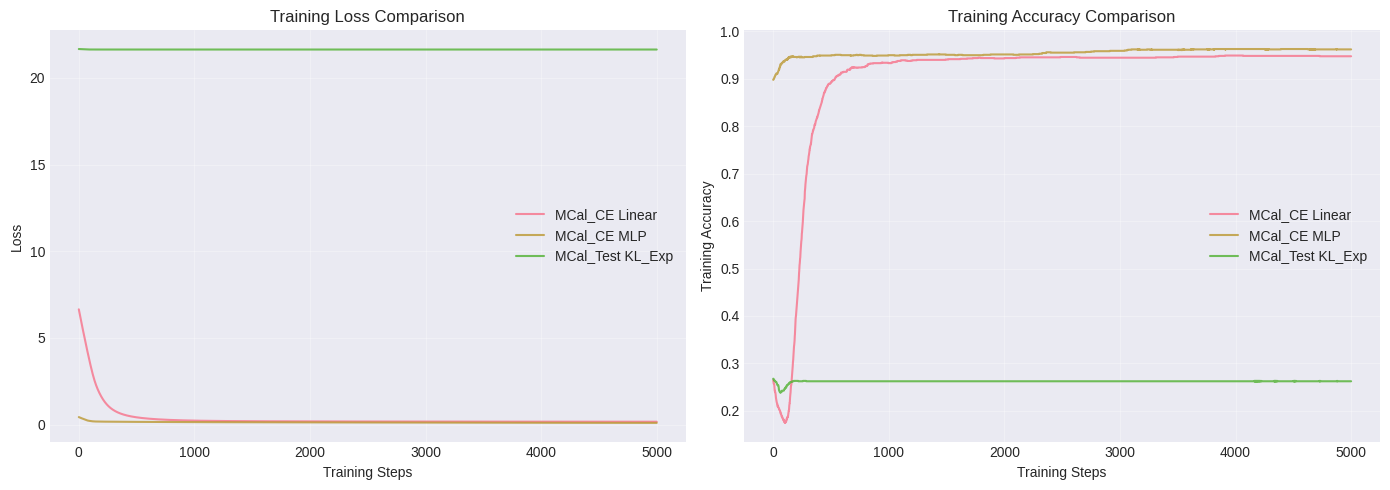

In [9]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(linear_stats['loss'], label='MCal_CE Linear', alpha=0.8)
ax1.plot(mlp_stats['loss'], label='MCal_CE MLP', alpha=0.8)
ax1.plot(kl_stats['loss'], label='MCal_Test KL_Exp', alpha=0.8)
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(linear_stats['acc'], label='MCal_CE Linear', alpha=0.8)
ax2.plot(mlp_stats['acc'], label='MCal_CE MLP', alpha=0.8)
ax2.plot(kl_stats['acc'], label='MCal_Test KL_Exp', alpha=0.8)
ax2.set_xlabel('Training Steps')
ax2.set_ylabel('Training Accuracy')
ax2.set_title('Training Accuracy Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison Summary

In [10]:
# Create comparison table
comparison_data = {
    'Metric': ['Test Accuracy', 'Agreement with Clean', 'KL Divergence', 'Missingness Bias', 'Final Training Loss', 'Final Training Acc', 'Parameters'],
    'Initial (Ablated)': [ablated_acc, agreement, kl_before_cal, mb_before_cal, '-', '-', '-'],
    'MCal_CE Linear': [calibrated_acc_linear, agreement_linear, kl_after_linear, mb_after_linear,
                   linear_stats['loss'][-1], linear_stats['acc'][-1],
                   sum(p.numel() for p in mcal_linear.parameters())],
    'MCal_CE MLP': [calibrated_acc_mlp, agreement_mlp, kl_after_mlp, mb_after_mlp,
                mlp_stats['loss'][-1], mlp_stats['acc'][-1],
                sum(p.numel() for p in mcal_mlp.parameters())],
    'MCal_Test KL_Exp': [calibrated_acc_kl, agreement_kl, kl_after_kl, mb_after_kl,
                    kl_stats['loss'][-1], kl_stats['acc'][-1],
                    sum(p.numel() for p in mcal_kl.parameters())]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n📊 COMPREHENSIVE COMPARISON")
print("=" * 100)
print(comparison_df.to_string(index=False))

# Determine winner
print("\n🏆 WINNER ANALYSIS:")
print("=" * 50)

# Find best performers
best_acc = max(calibrated_acc_linear, calibrated_acc_mlp, calibrated_acc_kl)
best_kl = min(kl_after_linear, kl_after_mlp, kl_after_kl)
best_mb = min(mb_after_linear, mb_after_mlp, mb_after_kl)

if calibrated_acc_linear == best_acc:
    print(f"MCal_CE Linear achieves best test accuracy: {calibrated_acc_linear:.4f}")
elif calibrated_acc_mlp == best_acc:
    print(f"MCal_CE MLP achieves best test accuracy: {calibrated_acc_mlp:.4f}")
elif calibrated_acc_kl == best_acc:
    print(f"MCal_Test KL_Exp achieves best test accuracy: {calibrated_acc_kl:.4f}")

if kl_after_linear == best_kl:
    print(f"MCal_CE Linear achieves best KL divergence: {kl_after_linear:.4f}")
elif kl_after_mlp == best_kl:
    print(f"MCal_CE MLP achieves best KL divergence: {kl_after_mlp:.4f}")
elif kl_after_kl == best_kl:
    print(f"MCal_Test KL_Exp achieves best KL divergence: {kl_after_kl:.4f}")

if mb_after_linear == best_mb:
    print(f"MCal_CE Linear achieves best Missingness Bias: {mb_after_linear:.4f}")
elif mb_after_mlp == best_mb:
    print(f"MCal_CE MLP achieves best Missingness Bias: {mb_after_mlp:.4f}")
elif mb_after_kl == best_mb:
    print(f"MCal_Test KL_Exp achieves best Missingness Bias: {mb_after_kl:.4f}")

print(f"\nParameter counts:")
print(f"  MCal_CE Linear: {sum(p.numel() for p in mcal_linear.parameters())} parameters")
print(f"  MCal_CE MLP: {sum(p.numel() for p in mcal_mlp.parameters())} parameters")
print(f"  MCal_Test KL_Exp: {sum(p.numel() for p in mcal_kl.parameters())} parameters")


📊 COMPREHENSIVE COMPARISON
              Metric Initial (Ablated)  MCal_CE Linear  MCal_CE MLP  MCal_Test KL_Exp
       Test Accuracy          0.912281        0.947368     0.961861          0.931350
Agreement with Clean          0.912281        0.950420     0.962624          0.932876
       KL Divergence          0.011147        0.000796     0.000373          0.003901
    Missingness Bias          0.011337        0.000807     0.000375          0.003838
 Final Training Loss                 -        0.168710     0.100984         21.639557
  Final Training Acc                 -        0.947368     0.961861          0.262395
          Parameters                 -       20.000000   148.000000          8.000000

🏆 WINNER ANALYSIS:
MCal_CE MLP achieves best test accuracy: 0.9619
MCal_CE MLP achieves best KL divergence: 0.0004
MCal_CE MLP achieves best Missingness Bias: 0.0004

Parameter counts:
  MCal_CE Linear: 20 parameters
  MCal_CE MLP: 148 parameters
  MCal_Test KL_Exp: 8 parameters


## Visualization: Performance Comparison

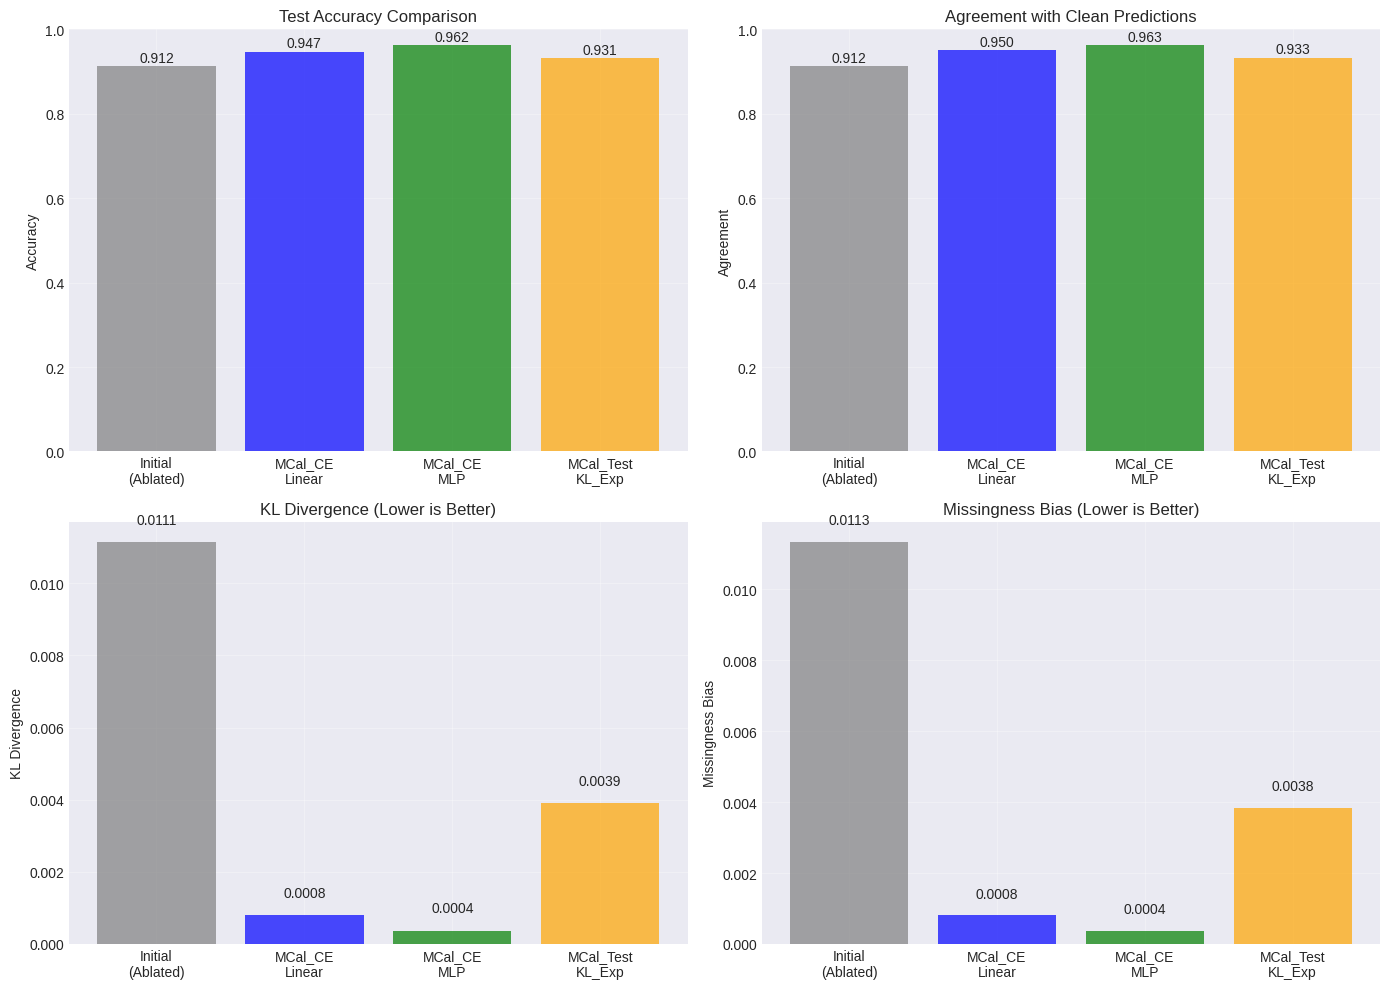

In [11]:
# Create bar plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
methods = ['Initial\n(Ablated)', 'MCal_CE\nLinear', 'MCal_CE\nMLP', 'MCal_Test\nKL_Exp']
accuracies = [ablated_acc, calibrated_acc_linear, calibrated_acc_mlp, calibrated_acc_kl]
colors = ['gray', 'blue', 'green', 'orange']

axes[0, 0].bar(methods, accuracies, color=colors, alpha=0.7)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center')

# Agreement with clean
agreements = [agreement, agreement_linear, agreement_mlp, agreement_kl]
axes[0, 1].bar(methods, agreements, color=colors, alpha=0.7)
axes[0, 1].set_ylabel('Agreement')
axes[0, 1].set_title('Agreement with Clean Predictions')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(True, alpha=0.3)

for i, v in enumerate(agreements):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center')

# KL Divergence
kl_divs = [kl_before_cal, kl_after_linear, kl_after_mlp, kl_after_kl]
axes[1, 0].bar(methods, kl_divs, color=colors, alpha=0.7)
axes[1, 0].set_ylabel('KL Divergence')
axes[1, 0].set_title('KL Divergence (Lower is Better)')
axes[1, 0].grid(True, alpha=0.3)

for i, v in enumerate(kl_divs):
    axes[1, 0].text(i, v + 0.0005, f'{v:.4f}', ha='center')

# Missingness Bias
mb_values = [mb_before_cal, mb_after_linear, mb_after_mlp, mb_after_kl]
axes[1, 1].bar(methods, mb_values, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('Missingness Bias')
axes[1, 1].set_title('Missingness Bias (Lower is Better)')
axes[1, 1].grid(True, alpha=0.3)

for i, v in enumerate(mb_values):
    axes[1, 1].text(i, v + 0.0005, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

## Save Results

In [12]:
# Save results
results_dir = project_root / 'experiments' / 'mcal_ce_results'
results_dir.mkdir(parents=True, exist_ok=True)

# Prepare results dictionary
results = {
    'dataset': 'MRI Brain Tumor',
    'num_classes': num_classes,
    'test_samples': len(true_labels),
    'ablation_method': 'Test-time patch dropout',
    'initial_metrics': {
        'clean_accuracy': float(clean_acc),
        'ablated_accuracy': float(ablated_acc),
        'agreement': float(agreement),
        'kl_divergence': float(kl_before_cal),
        'missingness_bias': float(mb_before_cal)
    },
    'mcal_ce_linear': {
        'test_accuracy': float(calibrated_acc_linear),
        'agreement_with_clean': float(agreement_linear),
        'kl_divergence': float(kl_after_linear),
        'missingness_bias': float(mb_after_linear),
        'final_training_loss': float(linear_stats['loss'][-1]),
        'final_training_acc': float(linear_stats['acc'][-1]),
        'num_parameters': int(sum(p.numel() for p in mcal_linear.parameters())),
        'training_steps': len(linear_stats['loss'])
    },
    'mcal_ce_mlp': {
        'test_accuracy': float(calibrated_acc_mlp),
        'agreement_with_clean': float(agreement_mlp),
        'kl_divergence': float(kl_after_mlp),
        'missingness_bias': float(mb_after_mlp),
        'final_training_loss': float(mlp_stats['loss'][-1]),
        'final_training_acc': float(mlp_stats['acc'][-1]),
        'num_parameters': int(sum(p.numel() for p in mcal_mlp.parameters())),
        'training_steps': len(mlp_stats['loss'])
    },
    'mcal_test_kl_exp': {
        'test_accuracy': float(calibrated_acc_kl),
        'agreement_with_clean': float(agreement_kl),
        'kl_divergence': float(kl_after_kl),
        'missingness_bias': float(mb_after_kl),
        'final_training_loss': float(kl_stats['loss'][-1]),
        'final_training_acc': float(kl_stats['acc'][-1]),
        'num_parameters': int(sum(p.numel() for p in mcal_kl.parameters())),
        'training_steps': len(kl_stats['loss'])
    }
}

# Save as JSON
with open(results_dir / 'mri_mcal_comparison.json', 'w') as f:
    json.dump(results, f, indent=2)

# Save comparison dataframe
comparison_df.to_csv(results_dir / 'mri_mcal_comparison.csv', index=False)

print(f"✅ Results saved to {results_dir}")
print(f"   - JSON: mri_mcal_comparison.json")
print(f"   - CSV: mri_mcal_comparison.csv")

✅ Results saved to /home/antonxue/foo/MCal/experiments/mcal_ce_results
   - JSON: mri_mcal_comparison.json
   - CSV: mri_mcal_comparison.csv


## Summary

This notebook compared three MCal calibration methods on the MRI Brain Tumor dataset:

1. **MCal_CE Linear Head**: Simple linear transformation (4 → 4) with cross-entropy loss
2. **MCal_CE MLP Head**: Multi-layer perceptron with residual connection (4 → 16 → 4) with cross-entropy loss
3. **MCal_Test KL_Exp**: Vector scaling calibration with KL divergence expectation loss

The experiment used test-time patch dropout to create ablated predictions and trained all models to calibrate these ablated predictions.

Key metrics evaluated:
- Test accuracy (how well the calibrated model predicts true labels)
- Agreement with clean predictions (how well calibration preserves original model behavior)
- KL divergence (distributional similarity to clean predictions)
- Missingness bias (aggregate-level distribution shift between clean and calibrated predictions)
- Model complexity (number of parameters)